In [22]:
# import the case 2 data
import pandas as pd

DATA_LOC = "../data/HR_data.csv"
ID_STR = "Individual"

raw_data = pd.read_csv(DATA_LOC)

# Split data into features and target; features would be the columns with 'HR_TD_', 'TEMP_TD', and 'EDA_TD' (about 48 columns);
# The rest goes to target variable Y
X = raw_data.filter(regex='HR_TD_|TEMP_TD|EDA_TD_|Individual')
Y = raw_data.drop(columns=X.columns)

X.head()

,HR_TD_Mean,HR_TD_Median,HR_TD_std,HR_TD_Min,HR_TD_Max,HR_TD_AUC,HR_TD_Kurtosis,HR_TD_Skew,HR_TD_Slope_min,HR_TD_Slope_max,...,EDA_TD_T_Kurtosis,EDA_TD_T_Skew,EDA_TD_T_Slope_min,EDA_TD_T_Slope_max,EDA_TD_T_Slope_mean,EDA_TD_T_Slope,EDA_TD_P_Peaks,EDA_TD_P_RT,EDA_TD_P_ReT,Individual
0,78.663878,76.70,7.480043,67.25,92.48,23048.450,-1.091448,0.369955,-0.7300,0.9775,...,1.345997,-1.379434,-0.000144,0.000138,0.000010,1.036040e-05,11,2.522727,2.075000,1
1,76.540732,76.61,2.584756,69.82,82.33,23959.920,-0.245338,0.338732,-0.3600,0.1900,...,0.887010,0.854067,-0.000146,0.000165,0.000009,7.714503e-06,15,2.214286,2.192308,1
2,78.173563,77.92,2.681255,72.22,82.80,20324.605,-0.615922,-0.233047,-0.6300,0.3575,...,0.205817,0.480581,-0.000112,0.000132,0.000002,1.799914e-06,10,1.972222,2.111111,1
3,83.073688,83.88,7.363598,69.42,96.12,24924.300,-0.866610,-0.046021,-0.4650,0.6500,...,2.488339,1.246665,-0.000455,0.000481,-0.000001,-1.355151e-07,12,1.886364,1.805556,1
4,72.281250,72.91,3.193762,64.95,79.98,23052.100,0.200401,-0.560948,-0.3725,0.3375,...,1.196508,1.592099,-0.000420,0.000334,0.000014,1.267198e-05,20,1.812500,1.926471,1


In [25]:
raw_data[ID_STR].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26])

In [43]:
# StandardScaler
from sklearn.preprocessing import StandardScaler

# We want to scale the features (X) but grouped by the individuals (ID column).
# This is because we want to preserve the relative differences between the features for each individual, while also ensuring that the features are on a similar scale across all individuals.
# The target are emotional states, so if we globally did it, a person with higher baseline heart rate would have higher values for all features, which might not be ideal.
scaler = StandardScaler()

X_scaled_individual = X.copy().groupby(raw_data[ID_STR]).transform(lambda x: scaler.fit_transform(x.to_frame())[:, 0] if x.ndim == 1 else scaler.fit_transform(x))
X_scaled_individual = X_scaled_individual.fillna(0)


For k=2 (Global Avg: 0.144):
  Cluster 0: Max Silhouette = 0.339 -> PASS
  Cluster 1: Max Silhouette = 0.223 -> PASS
  --> k=2 SATISFIES the rule!

For k=3 (Global Avg: 0.070):
  Cluster 0: Max Silhouette = 0.217 -> PASS
  Cluster 1: Max Silhouette = 0.150 -> PASS
  Cluster 2: Max Silhouette = 0.184 -> PASS
  --> k=3 SATISFIES the rule!

For k=4 (Global Avg: 0.078):
  Cluster 0: Max Silhouette = 0.186 -> PASS
  Cluster 1: Max Silhouette = 0.155 -> PASS
  Cluster 2: Max Silhouette = 0.169 -> PASS
  Cluster 3: Max Silhouette = 0.269 -> PASS
  --> k=4 SATISFIES the rule!

For k=5 (Global Avg: 0.062):
  Cluster 0: Max Silhouette = 0.223 -> PASS
  Cluster 1: Max Silhouette = 0.192 -> PASS
  Cluster 2: Max Silhouette = 0.156 -> PASS
  Cluster 3: Max Silhouette = 0.142 -> PASS
  Cluster 4: Max Silhouette = 0.214 -> PASS
  --> k=5 SATISFIES the rule!


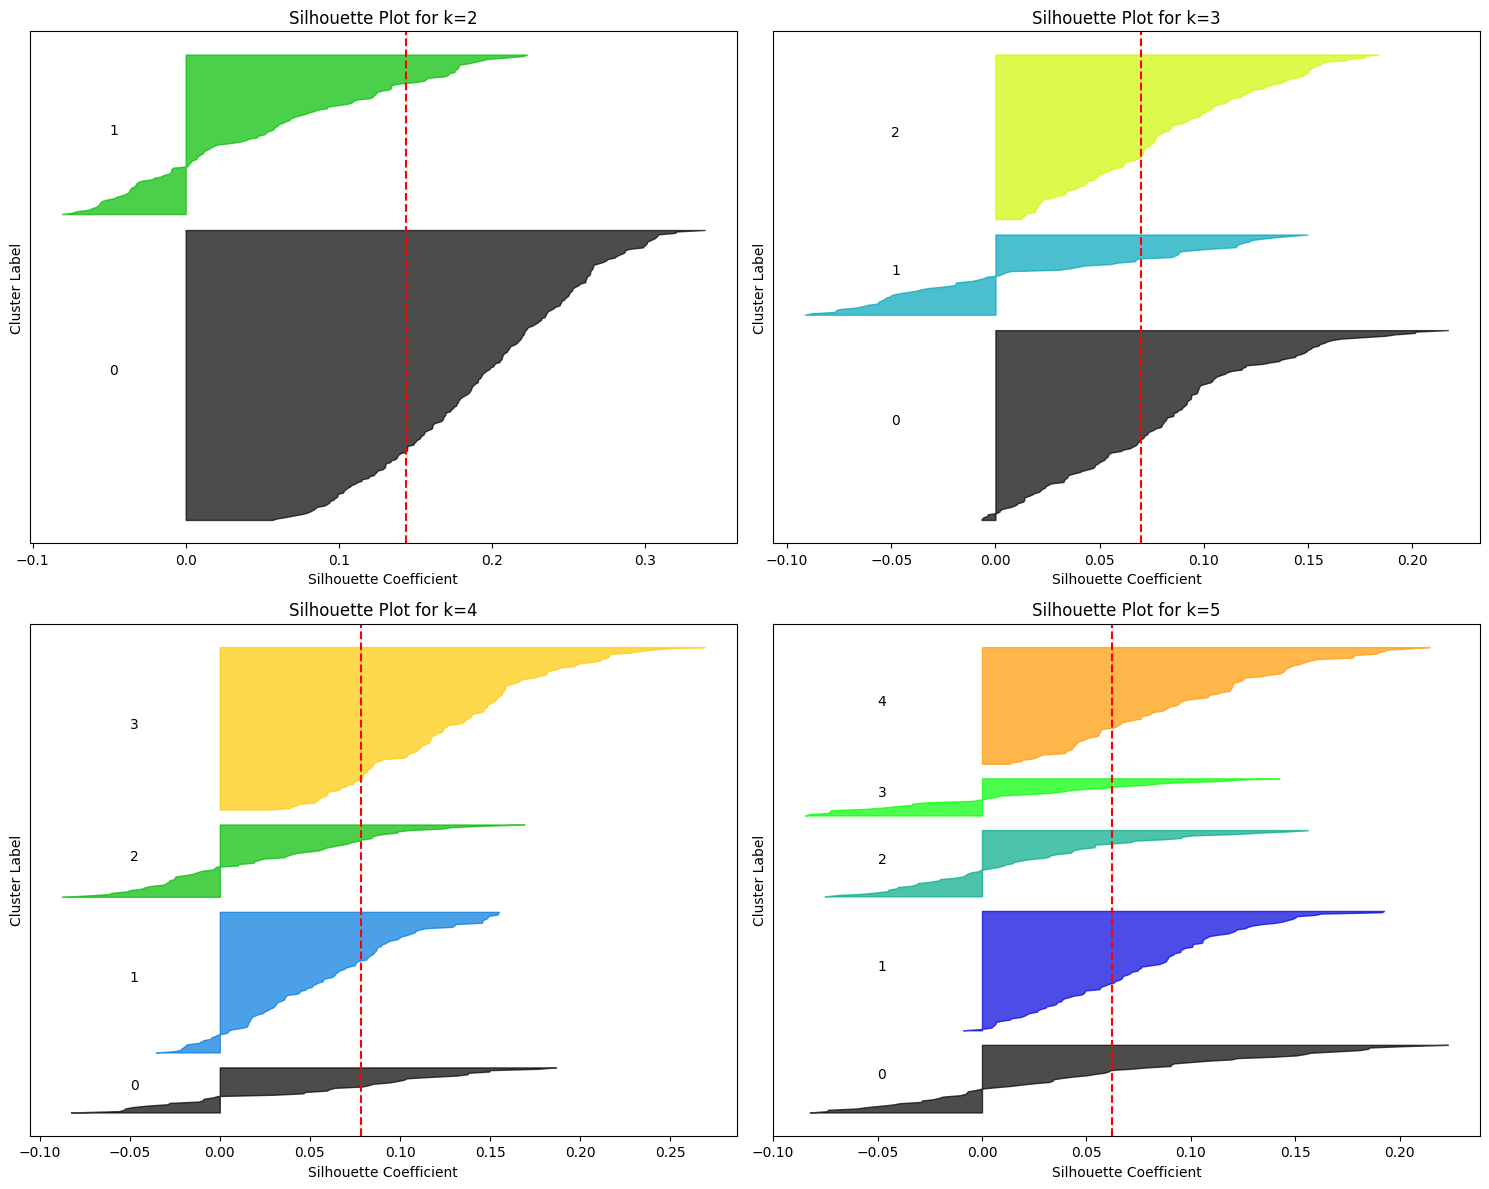

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm

# Variables (and their ranges)
k_range = range(2, 6) # Testing K from 2 to 5 (shared K now)

kmeans_silhouette_scores = []
gmm_silhouette_scores = []

#PLT plot stuff
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, k in enumerate(k_range):
    ax = axes[idx]
    # ------------------
    # K-MEANS CLUSTERING
    # ------------------
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled_individual)

    global_avg_score = silhouette_score(X_scaled_individual, cluster_labels)
    sample_scores = silhouette_samples(X_scaled_individual, cluster_labels)

    all_clusters_valid = True  # Variable for tracking if all clusters have valid silhouette scores
    print(f"\nFor k={k} (Global Avg: {global_avg_score:.3f}):")
    
    y_lower = 10  # Plot spacing reasons

    for i in range(k):
        ith_cluster_scores = sample_scores[cluster_labels == i]
        ith_cluster_scores.sort()

        # This is where we check if the cluster has at least one observation with a silhouette score above the global average
        max_in_cluster = ith_cluster_scores.max()
        has_obs_above_avg = max_in_cluster > global_avg_score
        
        print(f"  Cluster {i}: Max Silhouette = {max_in_cluster:.3f} -> {'PASS' if has_obs_above_avg else 'FAIL'}")
        if not has_obs_above_avg:
            all_clusters_valid = False
        
        size_cluster_i = ith_cluster_scores.shape[0]
        y_upper = y_lower + size_cluster_i
        color = cm.nipy_spectral(float(i) / k)
        
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_scores,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10  # move it up now (seperate the clusters for visual pleasure)
    
    if all_clusters_valid:  # We check which 'k' satisfies the rule of being above the average.
        print(f"  --> k={k} SATISFIES the rule!")
    
    # Plot stuff
    ax.set_title(f"Silhouette Plot for k={k}")
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Cluster Label")
    ax.axvline(x=global_avg_score, color="red", linestyle="--") # The Average Line
    ax.set_yticks([])  # Clear the y-axis labels

plt.tight_layout()
# plt.savefig('silhouette_scores_kmeans.png')
plt.show()


  Cluster 0: Max Silhouette = 0.227 -> PASS
  Cluster 1: Max Silhouette = 0.341 -> PASS
  --> k=2 SATISFIES the rule!
  Cluster 0: Max Silhouette = 0.110 -> PASS
  Cluster 1: Max Silhouette = 0.273 -> PASS
  Cluster 2: Max Silhouette = 0.227 -> PASS
  --> k=3 SATISFIES the rule!
  Cluster 0: Max Silhouette = 0.123 -> PASS
  Cluster 1: Max Silhouette = 0.196 -> PASS
  Cluster 2: Max Silhouette = 0.185 -> PASS
  Cluster 3: Max Silhouette = 0.196 -> PASS
  --> k=4 SATISFIES the rule!
  Cluster 0: Max Silhouette = 0.126 -> PASS
  Cluster 1: Max Silhouette = 0.189 -> PASS
  Cluster 2: Max Silhouette = 0.194 -> PASS
  Cluster 3: Max Silhouette = 0.197 -> PASS
  Cluster 4: Max Silhouette = 0.134 -> PASS
  --> k=5 SATISFIES the rule!
Valid choices for k (GMM) are: [2, 3, 4, 5]


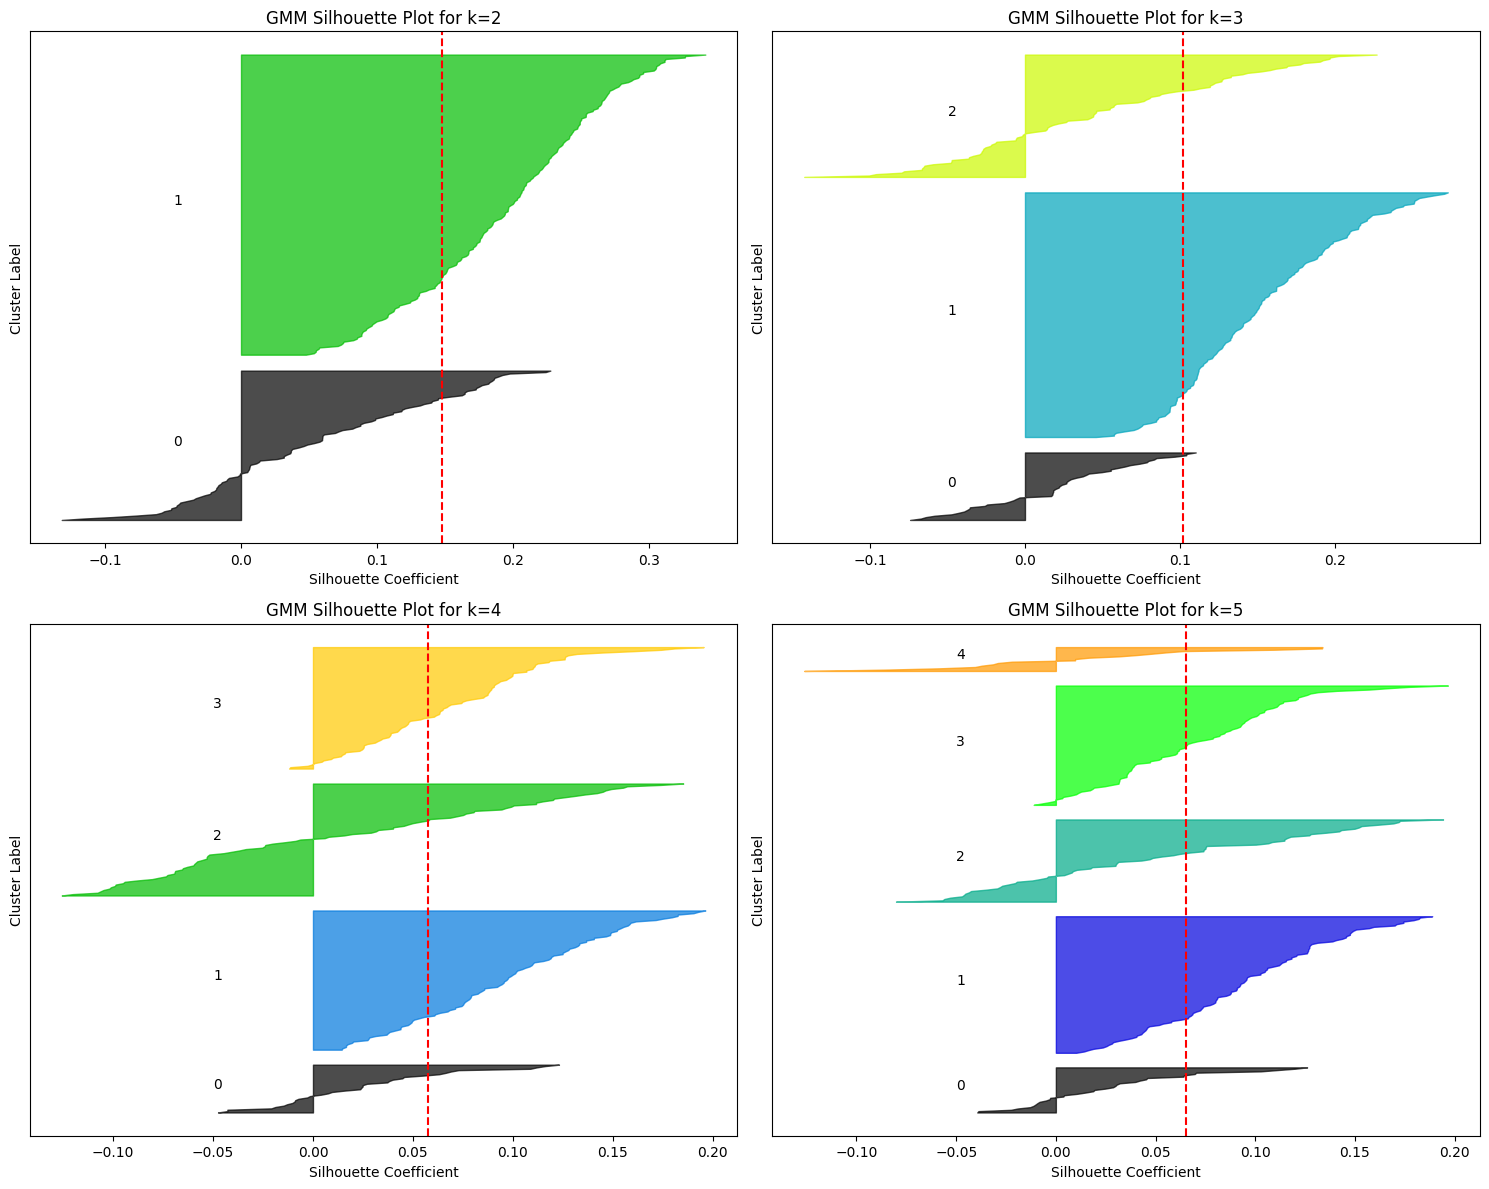

In [57]:
# Repeating for GMM
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

valid_ks_gmm = []

for idx, k in enumerate(k_range):
    ax = axes[idx]

    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    
    cluster_labels = gmm.fit_predict(X_scaled_individual)
    global_avg_score = silhouette_score(X_scaled_individual, cluster_labels)
    sample_scores = silhouette_samples(X_scaled_individual, cluster_labels)
    
    all_clusters_valid = True  # similarly here
    
    y_lower = 10
    
    for i in range(k):
        ith_cluster_scores = sample_scores[cluster_labels == i]
        ith_cluster_scores.sort()
        
        # Above the average?
        max_in_cluster = ith_cluster_scores.max() if len(ith_cluster_scores) > 0 else -1
        has_obs_above_avg = max_in_cluster > global_avg_score
        
        print(f"  Cluster {i}: Max Silhouette = {max_in_cluster:.3f} -> {'PASS' if has_obs_above_avg else 'FAIL'}")
        if not has_obs_above_avg:
            all_clusters_valid = False

        size_cluster_i = ith_cluster_scores.shape[0]
        y_upper = y_lower + size_cluster_i
        color = cm.nipy_spectral(float(i) / k)
        
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_scores,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10 
        
    if all_clusters_valid:
        valid_ks_gmm.append(k)
        print(f"  --> k={k} SATISFIES the rule!")
        
    # Formatting the plot
    ax.set_title(f"GMM Silhouette Plot for k={k}")
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Cluster Label")
    ax.axvline(x=global_avg_score, color="red", linestyle="--") # The Average Line
    ax.set_yticks([]) 

print(f"Valid choices for k (GMM) are: {valid_ks_gmm}")

plt.tight_layout()
# plt.savefig('gmm_silhouette_rule_proof.png') # Un-comment to save the plot!
plt.show()